<a href="https://colab.research.google.com/github/Priston11/Naruto-Episode-Analysis-ML/blob/main/Keras_Assignment_(2025_2026_B).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CW1 - Multimodal IMDB Analysis with Keras

## Introduction

In this assignment you will provided with a dataset containing a selection of films together with their posters in JPEG image format and their overviews in text format from the Internet Movie Database.

![Example](https://i.ibb.co/J3trT62/Screenshot-2024-09-22-214753.png)

You will be analysing this dataset by implementing and training two models: a **CNN** and an **LSTM**.

The CNN must classify film posters by the genre. Independently, the LSTM must classify film overviews by the genre. Finally, you will evaluate and critically comment your results in a short report. (Which of the two models was better at classifying films?)

## Structure of the assignment

This assignment is broken up into sections and you need to complete each section successively. The sections are the following:

1. Data Processing

  1.a. Image processing of the posters

  1.b. Natural language processing of the overviews

2. Models Definition

  2.a. CNN for the posters

  2.b. LSTM for the overviews

3. Models Training
4. Models Evaluation

In addition to this coding exercise, you must write a **2-page** report analysing and critically evaluating your model's results. Marks for the report will be awarded for depth of analysis and critical thinking skills. You should consider how well your model performs and WHY it does that—give specific examples and comment on their importance.

In [2]:
# Enter your module imports here, some modules are already provided

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os
import pathlib
import pandas as pd
from sklearn import model_selection
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.metrics import Precision, Recall
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, Flatten, Dense

In [3]:
# CodeGrade Tag Init1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Processing



In [4]:
# CodeGrade Tag Init2
# Do not edit, remove, or copy this cell

# This code will copy the images from your google drive into the colab file
# storage. Make sure the dataset is unzipped in your drive folder.
! mkdir /tmp/Multimodal_IMDB_dataset
! rsync -ah --info=progress2 /content/drive/MyDrive/Multimodal_IMDB_dataset/Images /tmp/Multimodal_IMDB_dataset/

        107.60M 100%  931.92kB/s    0:01:52 (xfr#4598, to-chk=0/4599)


In [5]:
# CodeGrade Tag Init3
# Do not edit, remove, or copy this cell


# Load the csv with the sample IDs and genres
csv_loc = "/content/drive/MyDrive/Multimodal_IMDB_dataset/IMDB_overview_genres.csv"
dataset = pd.read_csv(csv_loc)

# Split the dataset into training and testing
data_train, data_test = model_selection.train_test_split(dataset, test_size=0.2)

# Convert the labels to arrays
labels_train = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')
labels_test = np.array(data_test.drop(['Id', 'Genre', 'Overview'],axis=1)).astype('float32')

# List of the genre names
genres = np.array(data_train.drop(['Id', 'Genre', 'Overview'],axis=1).columns)

# List of overviews
overviews_train = np.array(data_train['Overview'])
overviews_test = np.array(data_test['Overview'])

# Build the file locations for the images
img_loc = "/tmp/Multimodal_IMDB_dataset/Images"

img_locs_train = np.array([[img_loc + '/' + id + '.jpg' for id in data_train['Id']]])
img_locs_test = [[img_loc + '/' + id + '.jpg' for id in data_test['Id']]]


# NOTICE: Provided function
# This function is provided to read in the image files from the folder
def parse_image(filename, label):
  image = tf.io.read_file(filename)
  image = tf.io.decode_jpeg(image)
  return image, label


### 1.a. Image processing of the posters

In [6]:
# CodeGrade Tag Init4
# Do not edit, remove, or copy this cell

# Create the initial datasets of film posters
list_posters_train_ds = tf.data.Dataset.from_tensor_slices((img_locs_train[0], labels_train))
list_posters_valid_ds = tf.data.Dataset.from_tensor_slices((img_locs_test[0], labels_test))

* **Create a function called ```img_process``` that converts the images to float32 datatype and resizes them to 64x64 pixels.**

In [40]:
# CodeGrade Tag Ex1a-i

def img_process(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (64, 64))
    image = image / 255.0
    return image, label

* **Create a function called ```img_augment``` that applies appropriate data augmentations to the dataset of movie posters. Choose transformations that you believe will preserve the semantic validity of poster images.**

In [37]:
# CodeGrade Tag Ex1a-ii

def img_augment(image, label):

    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

* **Using the `tf.data` API, construct the training and validation poster datasets as follows:**
  - For the **training** dataset, apply `parse_image`, then `img_process`, then `img_augment`.
  - For the **validation** dataset, apply `parse_image` and `img_process` (no augmentation).
  - Batch the datasets with batch size `64`.
  - Use appropriate `tf.data` pipeline optimisations (such as shuffling the training data, parallel mapping, and prefetching).

In [38]:
# CodeGrade Tag Ex1a-iii

AUTOTUNE = tf.data.AUTOTUNE

posters_train_ds = list_posters_train_ds \
    .map(parse_image, num_parallel_calls=AUTOTUNE) \
    .map(img_process, num_parallel_calls=AUTOTUNE) \
    .map(img_augment, num_parallel_calls=AUTOTUNE) \
    .cache() \
    .shuffle(1000) \
    .batch(64) \
    .prefetch(AUTOTUNE)


posters_valid_ds = list_posters_valid_ds \
    .map(parse_image, num_parallel_calls=AUTOTUNE) \
    .map(img_process, num_parallel_calls=AUTOTUNE) \
    .cache() \
    .batch(64) \
    .prefetch(AUTOTUNE)

### 1.b. Natural Language processing of the overviews

In [10]:
# CodeGrade Tag Init5
# Do not edit, remove, or copy this cell

# Create the initial datasets of the film overviews
list_overviews_train_ds = tf.data.Dataset.from_tensor_slices((overviews_train, labels_train))
list_overviews_valid_ds = tf.data.Dataset.from_tensor_slices((overviews_test, labels_test))

* **Using the `tf.data` API, construct the training and validation overviews datasets as follows:**
  - Batch the datasets with batch size `32`.
  - Use appropriate `tf.data` pipeline optimisations such as shuffling the training data and prefetching.

In [39]:
# CodeGrade Tag Ex1b-i

overviews_train_ds = list_overviews_train_ds \
    .shuffle(1000) \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)


overviews_valid_ds = list_overviews_valid_ds \
    .batch(32) \
    .prefetch(tf.data.AUTOTUNE)

* Build the vocabulary of the model by calling the ``encoder.adapt()`` method on the film overviews train data.

In [12]:
# CodeGrade Tag Ex1b-ii

VOCAB_SIZE = 10000

encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=100
)

# Adapt ONLY on training overviews
encoder.adapt(overviews_train)

* Print the first 200 words of the vocabulary you obtained.

In [13]:
# CodeGrade Tag Ex1b-iii

vocabulary = encoder.get_vocabulary()[:200]

print(vocabulary)

['', '[UNK]', np.str_('a'), np.str_('the'), np.str_('to'), np.str_('of'), np.str_('and'), np.str_('in'), np.str_('his'), np.str_('is'), np.str_('an'), np.str_('with'), np.str_('her'), np.str_('for'), np.str_('he'), np.str_('on'), np.str_('who'), np.str_('their'), np.str_('by'), np.str_('from'), np.str_('when'), np.str_('as'), np.str_('that'), np.str_('after'), np.str_('young'), np.str_('they'), np.str_('life'), np.str_('man'), np.str_('him'), np.str_('at'), np.str_('two'), np.str_('new'), np.str_('are'), np.str_('into'), np.str_('but'), np.str_('up'), np.str_('has'), np.str_('she'), np.str_('family'), np.str_('woman'), np.str_('love'), np.str_('out'), np.str_('one'), np.str_('find'), np.str_('must'), np.str_('friends'), np.str_('it'), np.str_('finds'), np.str_('be'), np.str_('school'), np.str_('world'), np.str_('story'), np.str_('them'), np.str_('where'), np.str_('about'), np.str_('while'), np.str_('group'), np.str_('have'), np.str_('girl'), np.str_('lives'), np.str_('father'), np.str_

## 2. Models Definition

### 2.a. CNN

In this question you will implement a custom Keras layer called `ResidualBlock`.  
This block will be used as the main building unit of the CNN in this section.

A residual block computes two tensors from the same input tensor `x`:

- a **main path** that learns a transformation $F(x)$, and
- a **skip path** that maps the input to a tensor $\mathrm{skip}(x)$ with the same shape as $F(x)$.

These two tensors are then added elementwise, and a final `ReLU` activation is applied:

$$
\mathrm{output} = \mathrm{ReLU}\big(F(x) + \mathrm{skip}(x)\big).
$$

More precisely, the block must have the following architecture.

* Main path

  The main path, corresponding to $F(x)$, must consist of the following layers in this exact order:

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`
    - `activation = "relu"`

  - **Dropout**

  - **3×3 convolution** with:
    - `filters = filters`
    - `strides = 1`
    - `padding = "same"`
    - **no activation function**

  - **Dropout**

* Skip path

  The skip path, corresponding to $\mathrm{skip}(x)$, must consist of a single layer:

  - **1×1 convolution** with:
    - `filters = filters`
    - `strides = strides`
    - `padding = "same"`


* Merge step

  The outputs of the two paths must then be combined as follows:

  - add the outputs elementwise, i.e. $F(x) + \mathrm{skip}(x)$;
  - apply a final ReLU activation to the sum (you can use `layers.ReLU` for this).


Graphically, the whole block will look like the following sketch:

  <img src="https://i.ibb.co/MkVXYFyg/Screenshot-2026-02-06-155017.png" width="300">


#### Implementation notes:
- Define the layers in `__init__` and implement the forward pass in `call`.
- Do not add any extra layers beyond those listed above.
- Recommended: you can use `kernel_initializer="he_normal"` for the convolutional layers, since this is often a good choice with ReLU activations, but this is not mandatory.


In [14]:
# CodeGrade Tag Ex2a-i

class ResidualBlock(layers.Layer):
    def __init__(self, filters, dropout=0.2, strides=1, name=None):
        super().__init__(name=name)

        # Main path
        self.conv1 = layers.Conv2D(
            filters=filters,
            kernel_size=(3,3),
            strides=strides,
            padding="same",
            activation="relu",
            kernel_initializer="he_normal"
        )

        self.drop1 = layers.Dropout(dropout)

        self.conv2 = layers.Conv2D(
            filters=filters,
            kernel_size=(3,3),
            strides=1,
            padding="same",
            activation=None,
            kernel_initializer="he_normal"
        )

        self.drop2 = layers.Dropout(dropout)

        # Skip path
        self.skip = layers.Conv2D(
            filters=filters,
            kernel_size=(1,1),
            strides=strides,
            padding="same",
            kernel_initializer="he_normal"
        )

        # ReLU layer
        self.relu = layers.ReLU()

    def call(self, x, training=False):

        # Main path
        main = self.conv1(x)
        main = self.drop1(main, training=training)
        main = self.conv2(main)
        main = self.drop2(main, training=training)

        # Skip path
        skip = self.skip(x)

        # Merge
        out = main + skip
        out = self.relu(out)

        return out

Using the Keras Functional API, create a convolutional neural network (CNN) that uses the `ResidualBlock` layer you implemented in the previous question.  
This model takes `64×64` RGB movie posters as input and outputs 25 genre probabilities (multi-label classification).

A few important points to consider:

- The input images have shape `(64, 64, 3)`.

- Before the first residual block, apply a convolutional layer called `StemConv` with 32 filters, kernel size `3×3`, `padding="same"`, and `ReLU` activation.

- Use four residual blocks in total, with filter sizes `32, 64, 128, 128`.

- Apply `MaxPooling2D(pool_size=2)` after `Block1`, `Block2`, and `Block3`, but not after `Block4`, so that the spatial dimensions go `64 → 32 → 16 → 8`.

- After the last residual block, use `GlobalAveragePooling2D` (not `Flatten`) to obtain a single feature vector.

- Then use one dense layer `Dense(256, activation="relu")`, followed by `Dropout(0.5)`.

- The output layer must be `Dense(25, activation="sigmoid")` because this is a multi-label classification problem.

- Use the layer names given below so that your model summary matches.

- Do not add any extra top-level layers beyond those listed below.

The following table lists the exact top-level layers of the model:

| Layer name  | Layer type             | Output shape          | Notes                                          |
| ----------- | ---------------------- | --------------------- | ---------------------------------------------- |
| `Input`     | InputLayer             | `(None, 64, 64, 3)`   | Input posters                                  |
| `StemConv`  | Conv2D                 | `(None, 64, 64, 32)`  | 3×3 conv, 32 filters, **ReLU**, padding="same" |
| `Block1`    | ResidualBlock          | `(None, 64, 64, 32)`  | filters=32, dropout=0.2, strides=1             |
| `Pool1`     | MaxPool2D              | `(None, 32, 32, 32)`  | pool_size=2                                    |
| `Block2`    | ResidualBlock          | `(None, 32, 32, 64)`  | filters=64, dropout=0.2, strides=1             |
| `Pool2`     | MaxPool2D              | `(None, 16, 16, 64)`  | pool_size=2                                    |
| `Block3`    | ResidualBlock          | `(None, 16, 16, 128)` | filters=128, dropout=0.2, strides=1            |
| `Pool3`     | MaxPool2D              | `(None, 8, 8, 128)`   | pool_size=2                                    |
| `Block4`    | ResidualBlock          | `(None, 8, 8, 128)`   | filters=128, dropout=0.2, strides=1            |
| `GAP`       | GlobalAveragePooling2D | `(None, 128)`         | averages each 8×8 feature map                  |
| `Dense1`    | Dense                  | `(None, 256)`         | use ReLU as activation function                |
| `DropDense` | Dropout                | `(None, 256)`         | dropout rate = 0.5                             |
| `Output`    | Dense                  | `(None, 25)`          | **sigmoid**                                    |


Recommended: you may use `kernel_initializer="he_normal"` for the convolutional and hidden dense layers, since this often works well with ReLU activations, but this is not mandatory.

In [15]:
# CodeGrade Tag Ex2a-ii

def build_cnn(num_labels=25, input_shape=(64, 64, 3)):
    inputs = keras.Input(shape=input_shape, name="Input")

    # Stem
    x = layers.Conv2D(
        32, (3,3),
        padding="same",
        activation="relu",
        kernel_initializer="he_normal",
        name="StemConv"
    )(inputs)

    # Block 1
    x = ResidualBlock(32, dropout=0.2, strides=1, name="Block1")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool1")(x)

    # Block 2
    x = ResidualBlock(64, dropout=0.2, strides=1, name="Block2")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool2")(x)

    # Block 3
    x = ResidualBlock(128, dropout=0.2, strides=1, name="Block3")(x)
    x = layers.MaxPooling2D(pool_size=2, name="Pool3")(x)

    # Block 4 (NO pooling after this)
    x = ResidualBlock(128, dropout=0.2, strides=1, name="Block4")(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D(name="GAP")(x)

    # Dense layers
    x = layers.Dense(
        256,
        activation="relu",
        kernel_initializer="he_normal",
        name="Dense1"
    )(x)

    x = layers.Dropout(0.5, name="DropDense")(x)

    # Output layer (MULTI-LABEL)
    outputs = layers.Dense(
        num_labels,
        activation="sigmoid",
        name="Output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs)

    return model


cnn_model = build_cnn()

* Print the model summary and confirm is has the same architecture as the one provided above.

In [16]:
# CodeGrade Tag Ex2a-iii

cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ StemConv (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block1 (ResidualBlock)          │ (None, 64, 64, 32)     │        19,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block2 (ResidualBlock)          │ (None, 32, 32, 64)     │        57,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block3 (ResidualBlock)          │ (None, 16, 16, 128)    │       229,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block4 (ResidualBlock)          │ (None, 8, 8, 128)      │       311,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DropDense (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,873 (2.51 MB)

 Trainable params: 658,873 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

* **Compile the model using the Adam Optimizer with a learning rate of ```1e-4``` and ```binary crossentropy``` loss function. For the metrics, use the ``Precision`` and ``Recall`` functions.**

In [17]:
# CodeGrade Tag Ex2a-iv

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[Precision(), Recall()]
)

### 2.b. LSTM model

* Set up the embedding layer by using ```tf.keras.layers.Embedding```. The ```input_dim``` is the length of the vocab, and the ```output_dim``` must be **265**. You should also set ```mask_zero=True```.

In [18]:
# CodeGrade Tag Ex2b-i

embedder = tf.keras.layers.Embedding(
    input_dim=len(encoder.get_vocabulary()),
    output_dim=265,
    mask_zero=True
)

* Use ```tf.keras.Sequential``` to build a keras sequential model, with the following layers:



  1.   encoder
  2.   embedder
  3.   biLSTM layer with 256 units, dropout 0.5, recurrent dropout 0.2 (make sure to use the right ```return_sequences``` parametre to be able to stack this layer with the following BiLSTM)
  4.   biLSTM layer with 128 units, dropout 0.5, recurrent dropout 0.2
  5.   dense layer with 128 units and relu activation function
  6.   dropout with rate 0.8
  7.   dense output layer with 25 units and sigmoid activation function



In [19]:
# CodeGrade Tag Ex2b-ii

lstm_model = tf.keras.Sequential([

    encoder,

    embedder,

    layers.Bidirectional(
        layers.LSTM(
            256,
            return_sequences=True,   # IMPORTANT for stacking
            dropout=0.5,
            recurrent_dropout=0.2
        )
    ),

    layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=False,
            dropout=0.5,
            recurrent_dropout=0.2
        )
    ),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.8),

    layers.Dense(25, activation='sigmoid')
])

* Print the model summary and confirm it has the same architecture as the outline provided above.

In [20]:
# CodeGrade Tag Ex2b-iii

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

* Compile the model with binary crossentropy loss, the adam optimizer, and the accuracy metric

In [21]:
# CodeGrade Tag Ex2b-iv

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. Models Training

* **Create a Model Checkpoint Callback that saves the weights of the best performing epoch, based on the validation loss, for both the CNN and the LSTM**

In [22]:
# CodeGrade Tag Ex3a-i

checkpoint_cnn_filepath = '/content/checkpoint_cnn.weights.h5'
checkpoint_lstm_filepath = '/content/checkpoint_lstm.weights.h5'

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cnn_callback = ModelCheckpoint(
    filepath=checkpoint_cnn_filepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

checkpoint_lstm_callback = ModelCheckpoint(
    filepath=checkpoint_lstm_filepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

### 3.a. CNN training

* **Train the CNN model for 50 epochs, using the callbacks you made previously. Store the losses and metrics to use later.**

In [23]:
# CodeGrade Tag Ex3a

cnn_history = cnn_model.fit(
    posters_train_ds,
    validation_data=posters_valid_ds,
    epochs=50,
    callbacks=[checkpoint_cnn_callback]
)

Epoch 1/50
     47/Unknown 159s 3s/step - loss: 1.8535 - precision: 0.1263 - recall: 0.3919

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.46744, saving model to /content/checkpoint_cnn.weights.h5

Epoch 1: finished saving model to /content/checkpoint_cnn.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - loss: 0.9536 - precision: 0.1495 - recall: 0.3292 - val_loss: 0.4674 - val_precision: 0.5076 - val_recall: 0.1768
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.3781 - precision: 0.2553 - recall: 0.2753
Epoch 2: val_loss improved from 0.46744 to 0.43847, saving model to /content/checkpoint_cnn.weights.h5

Epoch 2: finished saving model to /content/checkpoint_cnn.weights.h5
47/47 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - loss: 0.3630 - precision: 0.2770 - recall: 0.2714 - val_loss: 0.4385 - val_precision: 0.4204 - val_recall: 0.3471
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.3383 - precision: 0.3187 - recall: 0.2589
Epoch 3: val_loss improved from 0.43847 to 0.43284, saving model to /content/checkpoint_cnn.weights.h5

Epoch 3: finished saving model to /con

### 3.b. LSTM training

* **Train the model for 20 epochs** (this may take several minutes)**, using the callbacks you made previously. Store the losses and metrics to use later.**

In [24]:
# CodeGrade Tag Ex3b

lstm_history = lstm_model.fit(
    overviews_train_ds,
    validation_data=overviews_valid_ds,
    epochs=20,
    steps_per_epoch=len(overviews_train) // 32,
    validation_steps=len(overviews_test) // 32,
    callbacks=[checkpoint_lstm_callback]
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1546 - loss: 0.4491
Epoch 1: val_loss improved from None to 0.24101, saving model to /content/checkpoint_lstm.weights.h5

Epoch 1: finished saving model to /content/checkpoint_lstm.weights.h5
158/158 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.1913 - loss: 0.3527 - val_accuracy: 0.2003 - val_loss: 0.2410
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2525 - loss: 0.2663
Epoch 2: val_loss improved from 0.24101 to 0.22622, saving model to /content/checkpoint_lstm.weights.h5

Epoch 2: finished saving model to /content/checkpoint_lstm.weights.h5
158/158 ━━━━━━━━━━━━━━━━━━━━ 523s 3s/step - accuracy: 0.2512 - loss: 0.2602 - val_accuracy: 0.2476 - val_loss: 0.2262
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3031 - loss: 0.2464
Epoch 3: val_loss improved from 0.22622 to 0.22092, saving model to /content/checkpoint_lstm.weights.h5

Epoch 3: finished saving model to /content/checkpoint_lst

### 3.c. Load the best weights

* Now, load the best weights from your checkpoints of both your models.

In [25]:
# CodeGrade Tag Ex3c

cnn_model.load_weights(checkpoint_cnn_filepath)
lstm_model.load_weights(checkpoint_lstm_filepath)

# 4. Models Evaluation

### 4.a. CNN Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

dict_keys(['loss', 'precision', 'recall', 'val_loss', 'val_precision', 'val_recall'])


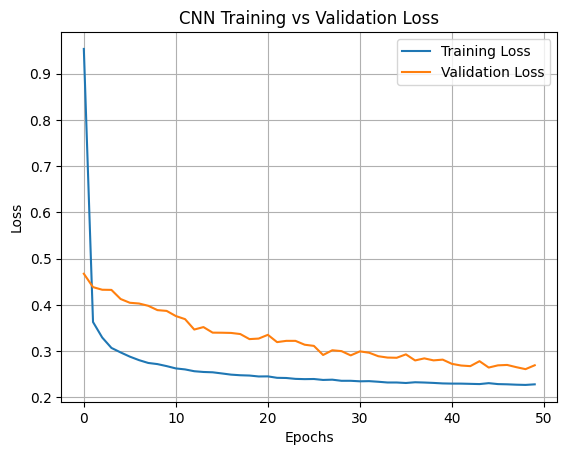

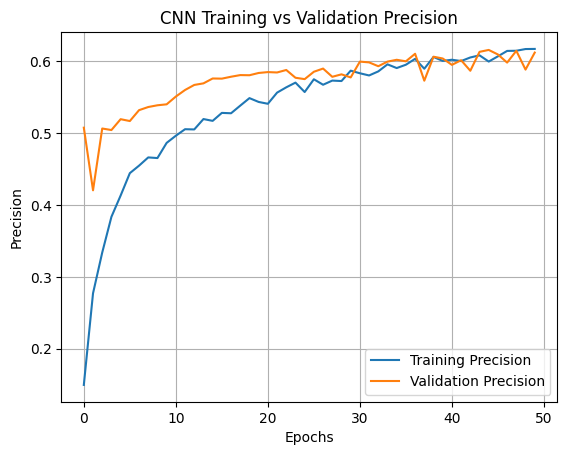

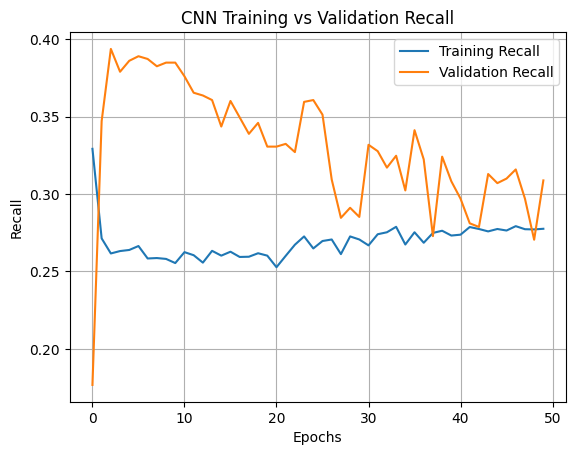

In [29]:
# CodeGrade Tag Ex4a-i

import matplotlib.pyplot as plt


print(cnn_history.history.keys())

# ----- LOSS PLOT -----
plt.figure()
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()


# ----- PRECISION PLOT -----
plt.figure()
plt.plot(cnn_history.history['precision'], label='Training Precision')
plt.plot(cnn_history.history['val_precision'], label='Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('CNN Training vs Validation Precision')
plt.legend()
plt.grid()
plt.show()


# ----- RECALL PLOT -----
plt.figure()
plt.plot(cnn_history.history['recall'], label='Training Recall')
plt.plot(cnn_history.history['val_recall'], label='Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('CNN Training vs Validation Recall')
plt.legend()
plt.grid()
plt.show()

### 4.b. LSTM Evaluation

* **Create plots using the losses and metrics. In your report, discuss these results and critically evaluate the model performance.**

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


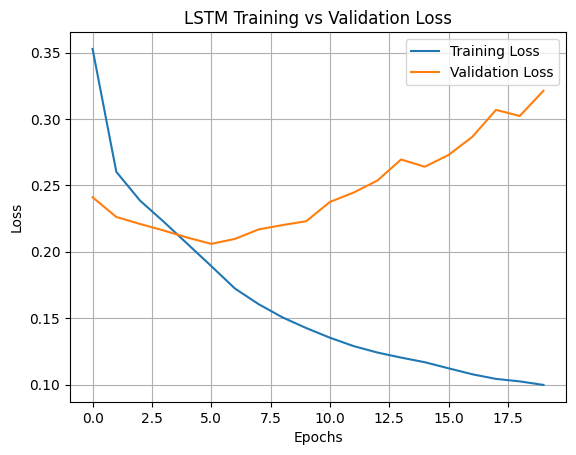

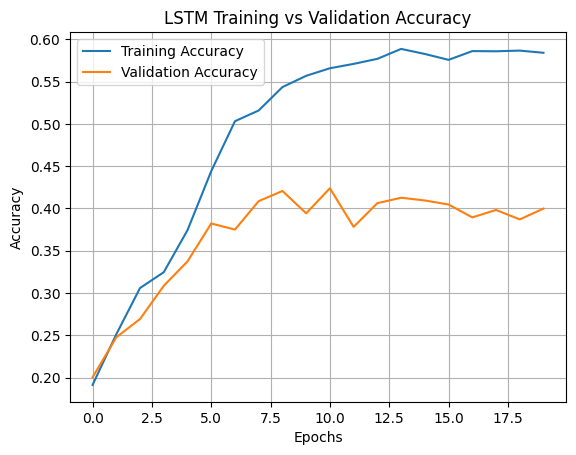

In [30]:
# CodeGrade Tag Ex4b-i

import matplotlib.pyplot as plt


print(lstm_history.history.keys())

# ----- LOSS PLOT -----
plt.figure()
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()


# ----- ACCURACY PLOT -----
plt.figure()
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

### 4.c. Produce examples for the report

* Choose a few films from the dataset, plot their posters and print their overviews. Use these example films to demonstrate the classification performance of the CNN model on their posters and of the LSTM model on their overview.

* Be sure to demonstrate the results of the multi-label classification. Compare, for each example film, the top three most probable genres predicted by the CNN and the top three most probable genres predicted by the LSTM with the ground truth genres.

* Include these examples in your report, and critically evaluate the performance of the model across the classes.

* Morevoer, you are allowed to add any other plot that could support your analysis, e.g. a confusion matrix.

**For this task, you can add new cells as you please.**

In [31]:

def get_top3(pred, genres):
    top3_idx = np.argsort(pred)[-3:][::-1]
    return [genres[i] for i in top3_idx]

# Get true labels
def get_true_labels(label, genres):
    return [genres[i] for i in range(len(label)) if label[i] == 1]

In [32]:
# Take a few samples
num_samples = 3

sample_images = []
sample_labels = []
sample_overviews = []

for img, label in posters_valid_ds.unbatch().take(num_samples):
    sample_images.append(img)
    sample_labels.append(label.numpy())

for text, label in overviews_valid_ds.unbatch().take(num_samples):
    sample_overviews.append(text.numpy().decode("utf-8"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


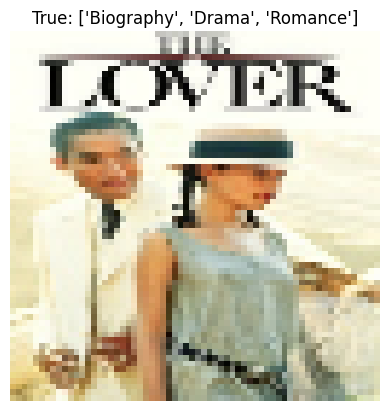

Overview:
In 1929 French Indochina, a French teenage girl embarks on a reckless and forbidden romance with a wealthy, older Chinese man, each knowing that knowledge of their affair will bring drastic consequenc ...

CNN Top 3: ['Drama', 'Comedy', 'Romance']
LSTM Top 3: ['Drama', 'Romance', 'Comedy']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


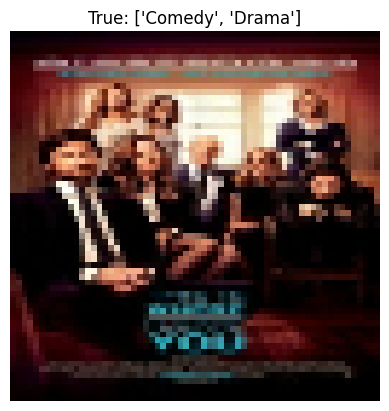

Overview:
Western Europe, 1945. The gentle, thoughtful, and sensitive Losey and the mean, base, and vicious Deming are two radically contrasting American soldiers who desert their platoons during the... ...

CNN Top 3: ['Drama', 'Thriller', 'Action']
LSTM Top 3: ['Drama', 'Biography', 'Romance']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


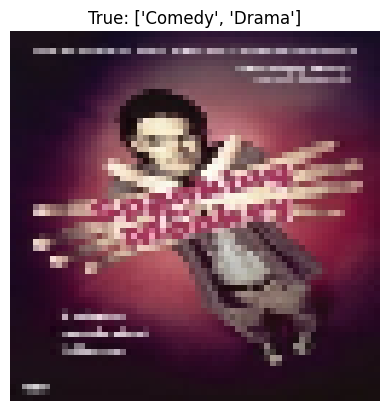

Overview:
A slobbering St. Bernard becomes the center of attention for a loving family, but must contend with a dog-napping veterinarian and his henchmen. ...

CNN Top 3: ['Drama', 'Comedy', 'Action']
LSTM Top 3: ['Drama', 'Comedy', 'Romance']


In [34]:
for i in range(num_samples):

    image = sample_images[i]
    label = sample_labels[i]
    overview = sample_overviews[i]

    # CNN prediction
    cnn_pred = cnn_model.predict(tf.expand_dims(image, axis=0))[0]

    # LSTM prediction (FIXED)
    lstm_pred = lstm_model.predict(tf.constant([overview]))[0]

    # Get results
    true_genres = get_true_labels(label, genres)
    cnn_top3 = get_top3(cnn_pred, genres)
    lstm_top3 = get_top3(lstm_pred, genres)

    # Plot image
    plt.imshow(image)
    plt.title(f"True: {true_genres}")
    plt.axis('off')
    plt.show()

    print("Overview:")
    print(overview[:200], "...")

    print("\nCNN Top 3:", cnn_top3)
    print("LSTM Top 3:", lstm_top3)
    print("="*50)

In [35]:
from sklearn.metrics import multilabel_confusion_matrix

y_true = []
y_pred = []

for img, label in posters_valid_ds.take(10):
    preds = cnn_model.predict(img)
    y_true.extend(label.numpy())
    y_pred.extend((preds > 0.5).astype(int))

cm = multilabel_confusion_matrix(y_true, y_pred)
print("Confusion matrix computed (multi-label)")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 993ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step
Confusion matrix computed (multi-label)
